In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import f1_score
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam
import joblib
import pickle
import warnings
warnings.filterwarnings("ignore")


In [2]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [4]:
start_program = time.time()
photos_csv = r"D:\yelp\yelpPhotos\yelp_photos\photos.csv"
photos_folder = r"D:\yelp\yelpPhotos\yelp_photos\photos""
# Load dataset
df = pd.read_csv(photos_csv)

In [20]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


In [22]:
df=df[['photo_id','label']]

In [24]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


DATA PREPROCESSING

In [28]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


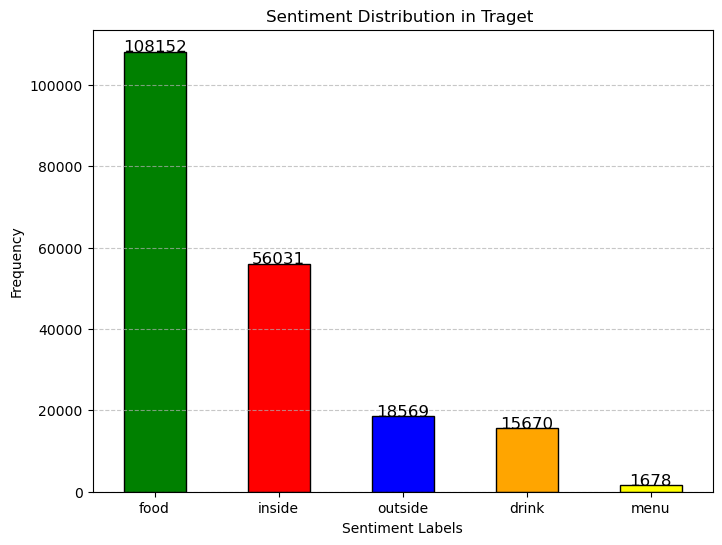

In [30]:
bar_plot(df['label'])

BALANCING THE DATASET

In [34]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
df_balanced

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
...,...,...
1495,b2Z_mH6elUbFfZ__rFmxWg,drink
1496,Hja-ujyebg1J0xyOzeaY_w,menu
1497,JLe7-8DzxieeiOHn-m1r5Q,outside
1498,FIw7ce992NJheBr9qEFHCA,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


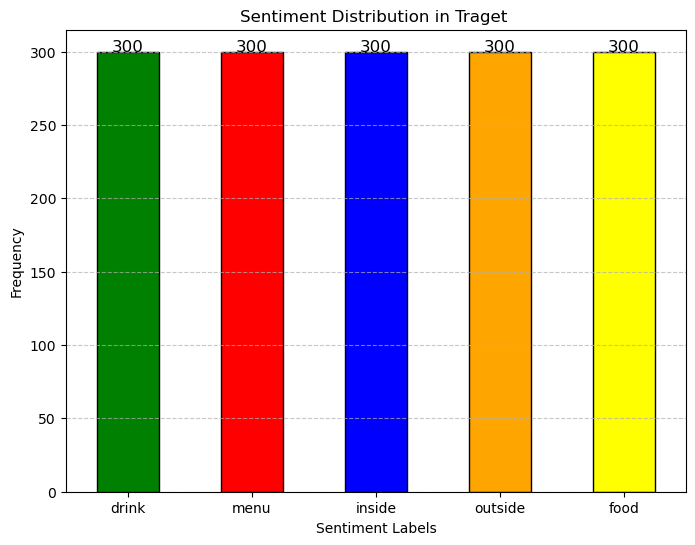

In [38]:
bar_plot(df_balanced['label'])

In [40]:
df = df_balanced

CONFIRMING THE COLUMN NAME

In [43]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [44]:
df.head(10)

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
5,4v5ns1DEc7DAz0r3xyrRqw,outside
6,bdtmWbdi6PRn_M1-aHYjcw,drink
7,t61K63S-DfSbufXgZpA_Ng,outside
8,pn4AVzlHlu4PhBpyDpb2wQ,menu
9,l_rMdwgrvjm2PyHyXBcBTw,food


In [47]:
# Get the first 10 records from the dictionary
first_10_records = dict(list(photo_id_to_path.items())[:10])

# Print them
print("First 10 records:", first_10_records)

First 10 records: {'--puCF1Lauwb3k6vrVVvfQ': 'D:\\Dataset\\photos\\--puCF1Lauwb3k6vrVVvfQ.jpg', '-10Ge63S6TdapDZV5ZGJLw': 'D:\\Dataset\\photos\\-10Ge63S6TdapDZV5ZGJLw.jpg', '-15xxjJWleNHNoApS8nXZA': 'D:\\Dataset\\photos\\-15xxjJWleNHNoApS8nXZA.jpg', '-3qJQmfAxo33Dp07QzkWtA': 'D:\\Dataset\\photos\\-3qJQmfAxo33Dp07QzkWtA.jpg', '-3yDzSGRk9m7z-N6bOH0Ag': 'D:\\Dataset\\photos\\-3yDzSGRk9m7z-N6bOH0Ag.jpg', '-5bUepz7K1gaHBD3LzApbQ': 'D:\\Dataset\\photos\\-5bUepz7K1gaHBD3LzApbQ.jpg', '-6buz7yJj7J-fAEBpzfPhw': 'D:\\Dataset\\photos\\-6buz7yJj7J-fAEBpzfPhw.jpg', '-BQqi2wtRzy3TjZj3ugjuw': 'D:\\Dataset\\photos\\-BQqi2wtRzy3TjZj3ugjuw.jpg', '-BW8LZAgLYSbC9Hka7v5yA': 'D:\\Dataset\\photos\\-BW8LZAgLYSbC9Hka7v5yA.jpg', '-BzkuAu2ShaH4qd1vp6xMg': 'D:\\Dataset\\photos\\-BzkuAu2ShaH4qd1vp6xMg.jpg'}


RESIZING THE IMAGE

In [50]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

Error occurred: cannot identify image file <_io.BytesIO object at 0x000002821005BB50>
Image path: D:\Dataset\photos\l_rMdwgrvjm2PyHyXBcBTw.jpg
1393
[[[[0.9529412  0.9529412  0.9607843 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.69411767 0.8117647  0.9137255 ]
   [0.7607843  0.8627451  0.9529412 ]
   [0.78431374 0.88235295 0.96862745]]

  [[0.95686275 0.95686275 0.9647059 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.8509804  0.9372549  1.        ]
   [0.8745098  0.95686275 1.        ]
   [0.8862745  0.9607843  1.        ]]

  [[0.9607843  0.9607843  0.96862745]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.89411765 0.95686275 1.        ]
   [0.8980392  0.9529412  0.99607843]
   [0.89411765 0.9411765  0.9882353 ]]

  ...

  [[0.5137255  0.41960785 0.37254903]
   [0.49803922 0.39607844 0.3372549 ]
   [0.40784314 0.30980393 0.22352941]
   ...
   [0.4274509

MAPPING THE LABELS

In [52]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [54]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

Shape of the image array:  (1393, 150528)
Shape of the target array:  (1393,)


Making functions for evaluations

In [56]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Step 2: Convert the confusion matrix to a DataFrame for better visualization
    cm_df = pd.DataFrame(cm, index=[reverse_label_mapping[i] for i in range(len(cm))], 
                         columns=[reverse_label_mapping[i] for i in range(len(cm))])
    
    print(cm_df)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", xticklabels=cm_df.columns, yticklabels=cm_df.columns)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [58]:
def plot_roc_curve(y_true, y_pred_bin):
     # Initialize LabelBinarizer
    lb = LabelBinarizer()

    # Binarize the true labels (one-hot encoding)
    y_true_bin = lb.fit_transform(y_true)   
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_true_bin.shape[1]):  # Iterate through all classes
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves in one plot
    plt.figure(figsize=(10, 8))
    
    # Plot ROC for each class
    for i in range(y_true_bin.shape[1]):
        label = lb.classes_[i]
        plt.plot(fpr[i], tpr[i], label=f'{reverse_label_mapping[label]} (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Labeling and Title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

    # Print AUC values for each class
    for i in range(y_true_bin.shape[1]):
        print(f'AUC for class {lb.classes_[i]}: {roc_auc[i]:.2f}')


SPLLITING THE DATA

In [61]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)

print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1114, 150528)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 150528)
Shape of y_test:  (279,)


class_count :  1    228
4    228
0    221
3    220
2    217
Name: count, dtype: int64


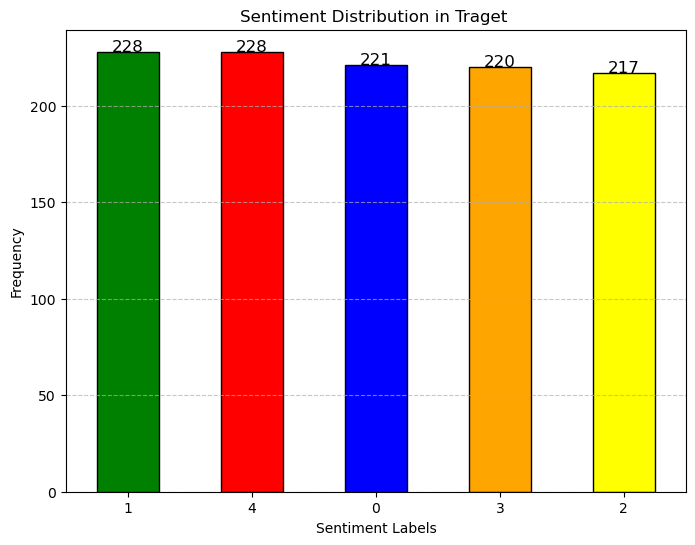

In [63]:
bar_plot(y_train)

In [65]:
# # Assuming X is your feature matrix and y is your target labels
# smote = SMOTE(random_state=42)
# x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# print("Shape of x_resampled: ",x_resampled.shape)
# print("Shape of y_resampled: ",y_resampled.shape)

In [67]:
# print("\nx_train : ", x_train)
# print("\ny_train : ", y_train)
# print("\nx_resampled : ", x_resampled)
# print("\ny_resampled : ", y_resampled)

In [69]:
# bar_plot(y_resampled)

BUILDING KNN MODEL

In [71]:
def model_result(model, x_train, y_train, x_test, y_test):
    # Evaluate on Training Data
    y_train_pred = model.predict(x_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Evaluate on Testing Data
    y_test_pred = model.predict(x_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Classification report for train and test
#     train_classification_report = classification_report(y_train, y_train_pred)
#     test_classification_report = classification_report(y_test, y_test_pred)
    
    # Get predicted probabilities instead of class predictions
    y_pred_proba_test = model.predict_proba(x_test)
    y_pred_proba_train = model.predict_proba(x_train)

    # Confusion Matrix for train and test
    train_conf_matrix = confusion_matrix(y_train, y_train_pred)
    test_conf_matrix = confusion_matrix(y_test, y_test_pred)

    # Print results for train data
    print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Train:\n ", train_conf_matrix)
    # F1 scores for train data
    f1_train = f1_score(y_train, y_train_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_train):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTraining Classification Report:")
#     print(train_classification_report)
    plot_confusion_matrix(y_train, y_train_pred)
    plot_roc_curve(y_train, y_pred_proba_train)

    # Print results for test data
    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Test:\n ", test_conf_matrix)
    # F1 scores for test data
    f1_test = f1_score(y_test, y_test_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_test):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTest Classification Report:")
#     print(test_classification_report)
    plot_confusion_matrix(y_test, y_test_pred)
    plot_roc_curve(y_test, y_pred_proba_test)

CHECKING INTERPRETIBILITY

In [73]:
def explain_with_lime(flattened_image, model, original_shape=(224, 224, 3), top_labels=5, num_samples= 500, num_features=5):
    """
    Explain the prediction of a k-NN model trained on flattened image data using LIME.

    Parameters:
    - flattened_image (numpy array): Flattened image array (1D).
    - knn_model: Trained k-NN model (must have a `predict_proba` method).
    - original_shape (tuple): Original shape of the image (height, width, channels).
    - top_labels (int): Number of top labels to explain (default: 5).
    - num_samples (int): Number of samples to generate for LIME (default: 1000).
    - num_features (int): Number of features to highlight in the explanation (default: 5).

    Returns:
    - explanation: LIME explanation object.
    - visualization: Image with highlighted regions.
    """
    
    # Reshape the flattened image back to its original shape
    image = flattened_image.reshape(original_shape)
    
    flat_image = image.reshape(1, -1)
    predicted_class = model.predict(flat_image)  # Predicted class
    print(f"The image belongs to class: {predicted_class}")

    # Create a wrapper function for k-NN predict_proba
    def model_predict_proba(images):
        """
        Reshape the images to 2D and predict probabilities using the k-NN model.
        """
        # Flatten the images
        
        flattened_images = images.reshape(images.shape[0], -1)  # Shape: (n_samples, height * width * channels)
        # Predict probabilities
        return model.predict_proba(flattened_images)

    # Create LIME explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the model's prediction on the image
    explanation = explainer.explain_instance(
        image, 
        model_predict_proba, 
        top_labels=top_labels, 
        hide_color=0, 
        num_samples=num_samples
    )

    # Get the explanation for the top predicted label
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=num_features, 
        hide_rest=False
    )

    # Visualize the explanation
    visualization = mark_boundaries(temp / 2 + 0.5, mask)
    plt.imshow(visualization)
    plt.axis('off')  # Hide axes
    plt.show()

    return explanation, visualization

In [75]:
# save trained models
def save_model(model, file_path, file_name):
    joblib.dump(model, file_path + file_name + ".joblib")
    with open(file_path + file_name + ".pkl", "wb") as file:
        pickle.dump(model, file)

Training Time: 0.18 seconds


  File "C:\Users\Gaurav\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Gaurav\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Gaurav\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Gaurav\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



Training Accuracy: 65.80%

Confusion matrix Train:
  [[180   0   0  25  16]
 [ 40 117   6  37  28]
 [ 38  13 138  20   8]
 [ 35   7   9 151  18]
 [ 39  10   7  25 147]]

F1 Scores for each class:
food: 0.6510
inside: 0.6240
outside: 0.7321
drink: 0.6318
menu: 0.6607
         food  inside  outside  drink  menu
food      180       0        0     25    16
inside     40     117        6     37    28
outside    38      13      138     20     8
drink      35       7        9    151    18
menu       39      10        7     25   147


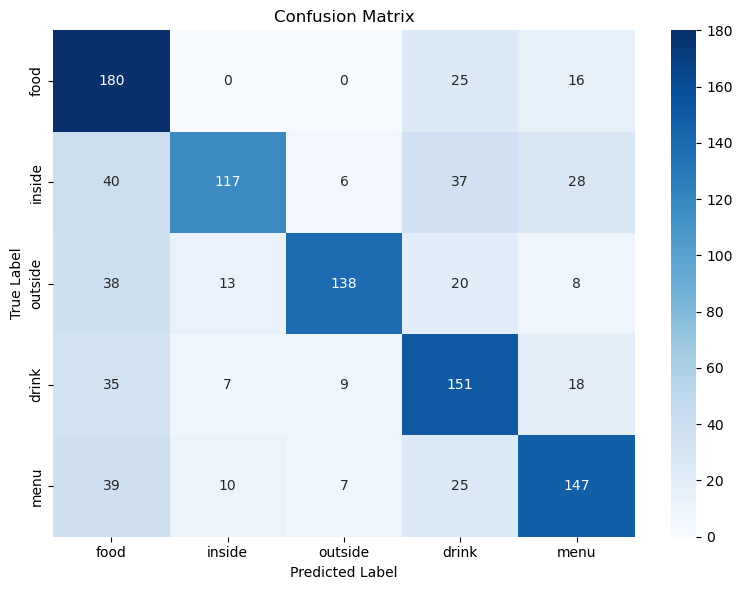

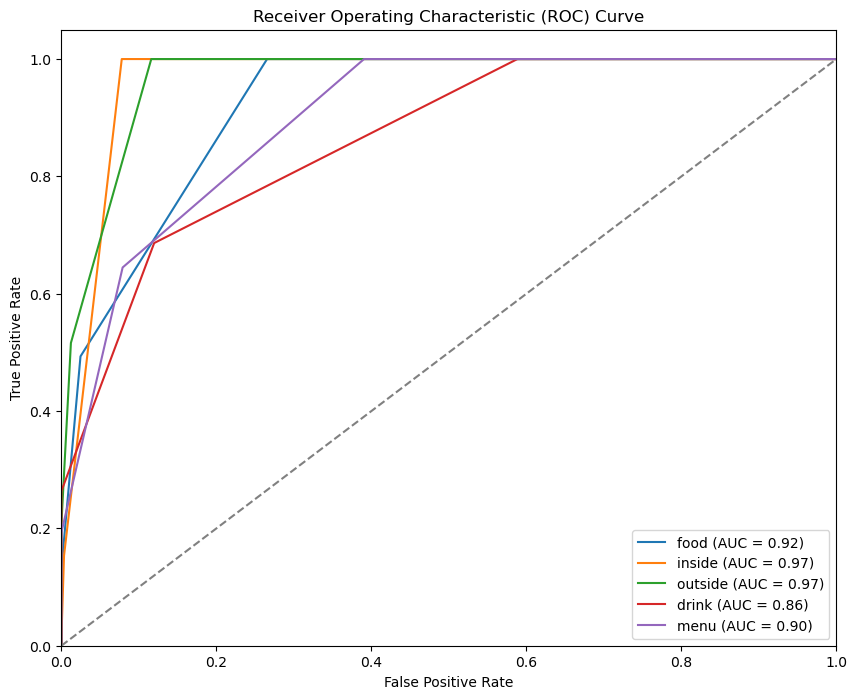

AUC for class 0: 0.92
AUC for class 1: 0.97
AUC for class 2: 0.97
AUC for class 3: 0.86
AUC for class 4: 0.90

Test Accuracy: 35.13%

Confusion matrix Test:
  [[16  2  1 26  9]
 [10  9  3 16 14]
 [12  2 22 17  5]
 [14  4  3 27 10]
 [14  3  5 11 24]]

F1 Scores for each class:
food: 0.2667
inside: 0.2500
outside: 0.4783
drink: 0.3484
menu: 0.4034
         food  inside  outside  drink  menu
food       16       2        1     26     9
inside     10       9        3     16    14
outside    12       2       22     17     5
drink      14       4        3     27    10
menu       14       3        5     11    24


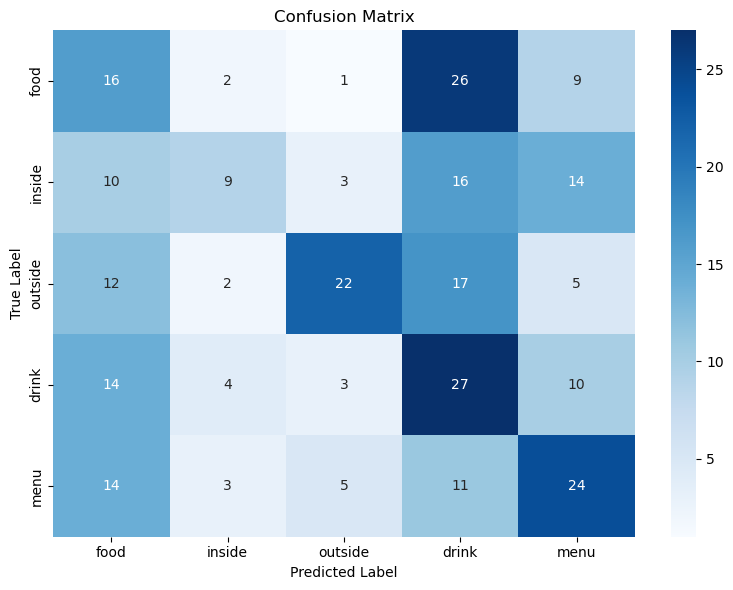

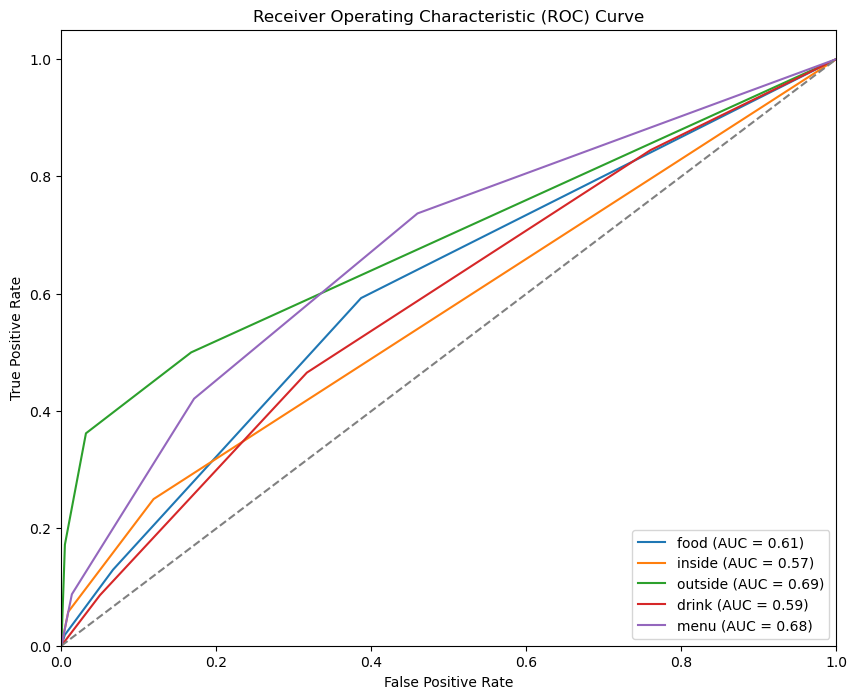

AUC for class 0: 0.61
AUC for class 1: 0.57
AUC for class 2: 0.69
AUC for class 3: 0.59
AUC for class 4: 0.68
Model Saved Successfully


In [77]:
# Initialize the KNN model with k=3
knn = KNeighborsClassifier(n_neighbors=3)


start_time = time.time()
# Train the KNN model
knn.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

model_result(knn, x_train, y_train, x_test, y_test)
save_model(knn, "D:\Models" , "knn_photo")
print("Model Saved Successfully")

PRINTING THE RESULTS

In [78]:
print(x_test)
print(y_test)

print(x_test[0].shape)

# print(x_images)
# print(y_labels)

[[0.36078432 0.6117647  0.99607843 ... 0.12941177 0.22352941 0.31764707]
 [0.2        0.10196079 0.01568628 ... 0.25882354 0.22745098 0.15294118]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.3882353  0.40392157 0.40784314 ... 0.827451   0.7529412  0.627451  ]
 [0.28627452 0.1882353  0.10980392 ... 0.4        0.27058825 0.19607843]
 [0.72156864 0.7176471  0.70980394 ... 0.42352942 0.52156866 0.5372549 ]]
[2 4 2 2 4 3 2 4 2 4 0 1 4 3 0 3 4 2 1 2 2 0 4 4 0 2 1 0 0 4 3 2 2 2 2 0 1
 2 4 4 1 3 4 0 1 1 0 0 4 1 3 2 3 4 2 1 2 0 1 4 1 1 3 2 0 1 2 4 2 4 1 2 3 1
 0 0 0 2 2 1 4 3 0 0 0 2 0 3 3 0 0 0 3 3 1 2 1 3 2 2 2 1 2 4 0 4 3 4 3 1 3
 2 3 4 0 1 2 1 1 3 3 0 1 3 1 0 4 3 4 0 2 3 0 0 3 3 0 3 0 4 3 2 2 2 4 3 3 3
 1 4 2 4 3 2 3 0 0 1 2 0 2 2 4 2 3 0 0 0 2 2 1 3 2 2 2 1 4 4 1 2 2 0 3 0 1
 3 3 4 0 4 2 0 1 1 2 3 1 1 4 3 2 1 2 0 4 4 0 2 3 4 3 4 3 1 1 0 2 3 0 1 0 2
 4 1 4 0 4 1 4 3 1 1 4 4 3 3 1 3 4 4 3 2 0 3 4 1 2 4 4 3 4 3 1 3 4 2 4 1 0
 1 4 0 3 0 4 4 0 3 3 1 1 1 0 0 

The image belongs to class: [2]


  0%|          | 0/500 [00:00<?, ?it/s]

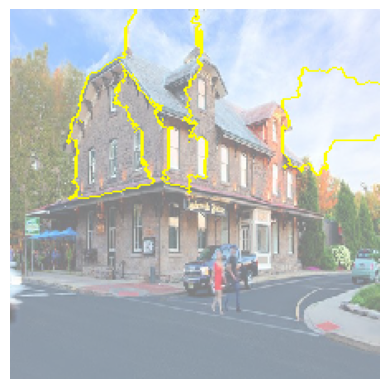

(<lime.lime_image.ImageExplanation at 0x283584cecf0>,
 array([[[0.68039215, 0.80588233, 0.99803925],
         [0.6843137 , 0.80784315, 0.99803925],
         [0.69215685, 0.80980396, 1.        ],
         ...,
         [0.8647059 , 0.89607847, 0.99215686],
         [0.8666667 , 0.9       , 0.9901961 ],
         [0.87254906, 0.9078431 , 0.99803925]],
 
        [[0.68039215, 0.80980396, 1.        ],
         [0.6764706 , 0.8019608 , 0.9941176 ],
         [0.6784314 , 0.8019608 , 0.99215686],
         ...,
         [0.8627451 , 0.8980392 , 0.99215686],
         [0.85882354, 0.89411765, 0.9882353 ],
         [0.85882354, 0.89411765, 0.9843137 ]],
 
        [[0.672549  , 0.80588233, 1.        ],
         [0.6745098 , 0.8019608 , 0.99803925],
         [0.6784314 , 0.8039216 , 1.        ],
         ...,
         [0.85490197, 0.89607847, 0.9882353 ],
         [0.8509804 , 0.8901961 , 0.9882353 ],
         [0.85294116, 0.89215684, 0.9901961 ]],
 
        ...,
 
        [[0.57058823, 0.61764705, 

In [122]:
explain_with_lime(X_val[0], knn)

model performs very well on the training data (85.80%) but poorly on the test data (35.12%), indicating overfitting. This means KNN model memorized the training data but failed to generalize well to unseen data.

TUNING THE KNN MODEL  (Hyperparameter Optimization)

In [86]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Training Time: 61.14 seconds
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
Best Cross-Validation Score: 0.4084

Training Accuracy: 51.35%

Confusion matrix Train:
  [[101  14   6  77  23]
 [ 16  73  28  93  18]
 [ 21  18 119  50   9]
 [ 25  16  11 149  19]
 [ 10  13  11  64 130]]

F1 Scores for each class:
food: 0.5127
inside: 0.4033
outside: 0.6071
drink: 0.4564
menu: 0.6089
         food  inside  outside  drink  menu
food      101      14        6     77    23
inside     16      73       28     93    18
outside    21      18      119     50     9
drink      25      16       11    149    19
menu       10      13       11     64   130


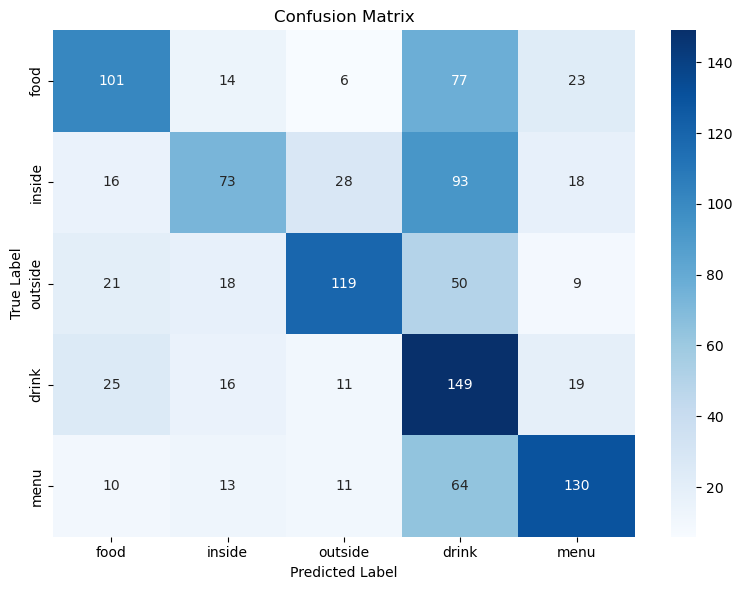

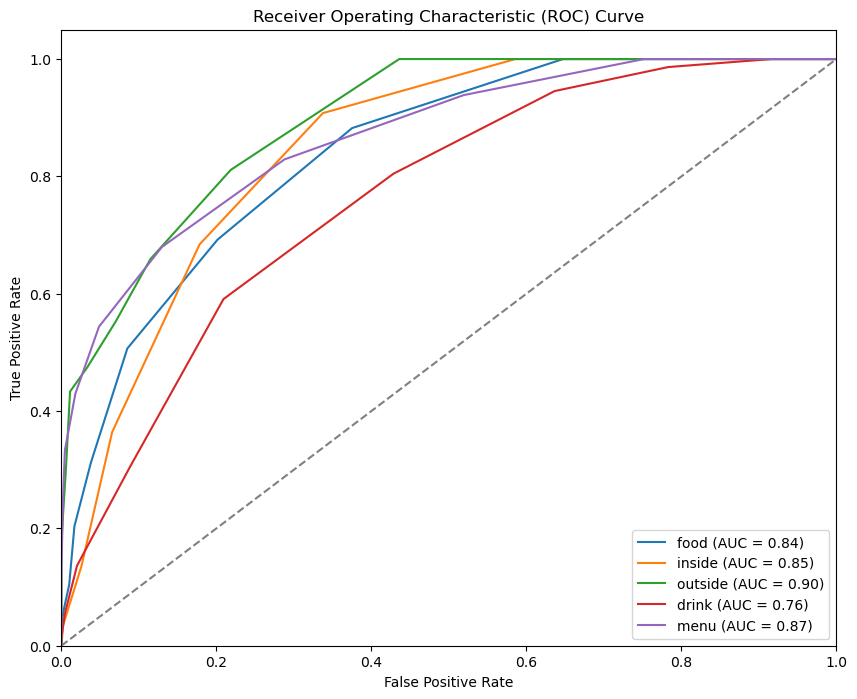

AUC for class 0: 0.84
AUC for class 1: 0.85
AUC for class 2: 0.90
AUC for class 3: 0.76
AUC for class 4: 0.87

Test Accuracy: 41.94%

Confusion matrix Test:
  [[14  2  2 28  8]
 [ 4 13  7 27  1]
 [ 6  9 25 18  0]
 [10  6  0 35  7]
 [ 5  4  2 16 30]]

F1 Scores for each class:
food: 0.3011
inside: 0.3023
outside: 0.5319
drink: 0.3846
menu: 0.5825
         food  inside  outside  drink  menu
food       14       2        2     28     8
inside      4      13        7     27     1
outside     6       9       25     18     0
drink      10       6        0     35     7
menu        5       4        2     16    30


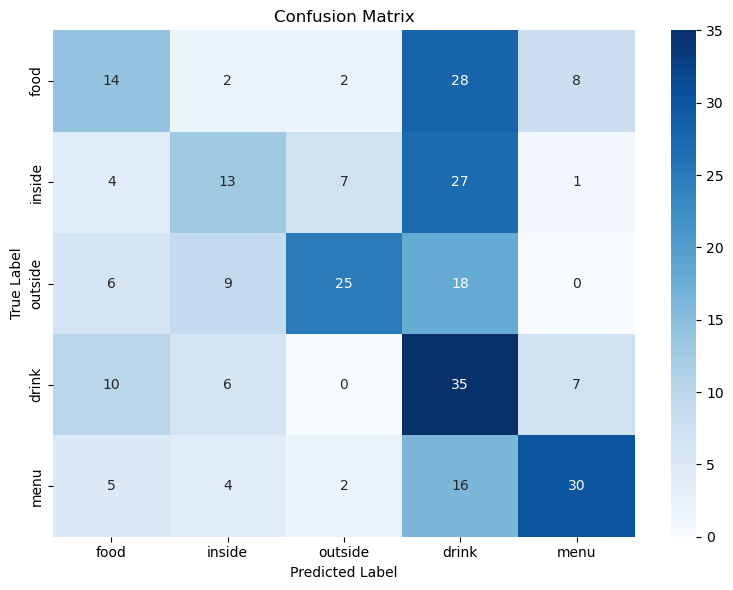

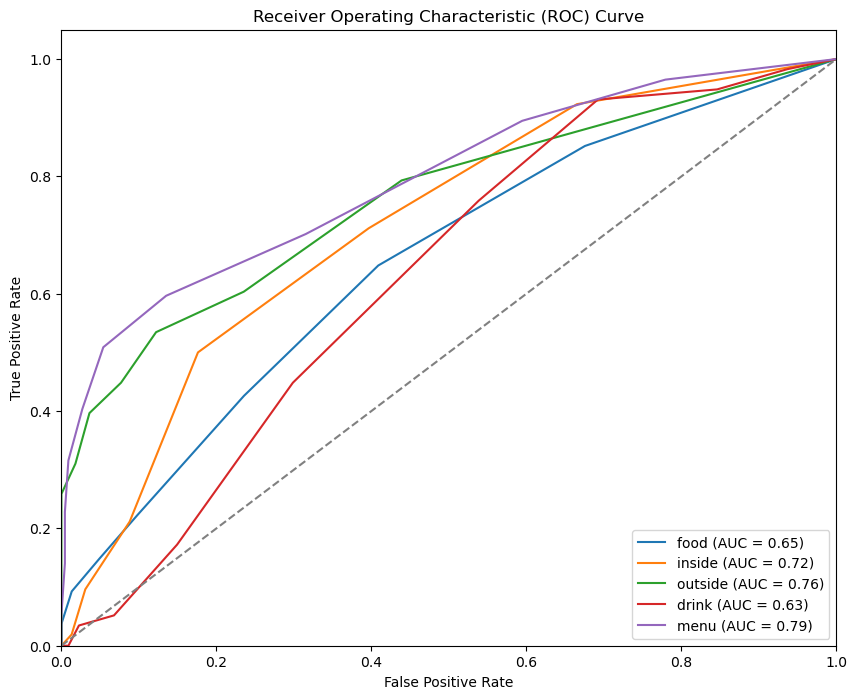

AUC for class 0: 0.65
AUC for class 1: 0.72
AUC for class 2: 0.76
AUC for class 3: 0.63
AUC for class 4: 0.79
Model Saved Successfully


In [88]:
# Define the parameter grid (you can adjust the range of k values here)
param_grid = {
    'n_neighbors': [3, 7, 11],
    'metric': ['euclidean', 'manhattan']  # Different distance metrics
}

# Create the GridSearchCV object with 5-fold cross-validation
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

start_time = time.time()
# Fit the model to the training data
grid_search.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Display the best parameters from GridSearch
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Get the best model after GridSearch
best_knn = grid_search.best_estimator_

model_result(best_knn, x_train, y_train, x_test, y_test)
save_model(best_knn, "D:\Models", "grid_search_knn_photo")
print("Model Saved Successfully")